# Handwritten Digit Classification using CNN & RNN

### Data_Preprocessing

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import transforms

import torchvision
from torchvision.datasets import MNIST
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

trainset=MNIST(root='./Data',train=True,download=True,transform=transform)
testset=MNIST(root="./Data",train=False,download=True,transform=transform)

In [7]:
train_loader=DataLoader(trainset,shuffle=True,batch_size=64)
test_loader=DataLoader(testset,shuffle=False,batch_size=64)

print(f'Training samples : {len(trainset):,}')
print(f'Test samples     : {len(testset):,}')
print(f'Input tensor shape (one image): {trainset[0][0].shape}')  # [1, 28, 28]

Training samples : 60,000
Test samples     : 10,000
Input tensor shape (one image): torch.Size([1, 28, 28])


In [13]:
# Conv2d	Learns features like edges, curves, corners
# BatchNorm	Normalises outputs — stabilises and speeds training
# ReLU	Activation function — removes negatives, adds non-linearity
# MaxPool	Reduces spatial size, keeps the strongest features
# Dropout	Randomly zeros neurons — prevents overfitting
# Linear	Fully connected layer — does final classification

### Defining_The_CNN_Model

In [39]:
class CNN(nn.Module):

    def __init__(self, num_classes=10):     # num_classes tells expected no. of output of the model
        super(CNN, self).__init__()

        # ── Conv Block 1 ───────────────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 28×28 → 14×14
        )

        # ── Conv Block 2 ───────────────────────────────────────
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 14×14 → 7×7
        )

        # ── Conv Block 3 ───────────────────────────────────────
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
            # No MaxPool — preserve spatial info before flattening
        )

        # ── Fully Connected Classifier ──────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # [128 × 7 × 7] → [6272]
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),              # strong regularisation
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)     # 10 output scores
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x   # raw logits; CrossEntropyLoss applies softmax internally


# Instantiate & move to device
model = CNN(num_classes=10).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training & Evaluation Of The Model

In [12]:
epochs = 10
model.train()
for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        
        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(train_loader)}")

epoch=1/10 & loss=0.16757936461586387
epoch=2/10 & loss=0.07099024257334724
epoch=3/10 & loss=0.057588870083835765
epoch=4/10 & loss=0.04702947402411679
epoch=5/10 & loss=0.0371095448477671
epoch=6/10 & loss=0.033265534723584636
epoch=7/10 & loss=0.02821067394550265
epoch=8/10 & loss=0.02768004934865348
epoch=9/10 & loss=0.02347561823078917
epoch=10/10 & loss=0.017949196804586058


In [15]:
# Evaludate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model.forward(images)
        # values, indices = torch.max(outputs, dim=1)
        _, predicted  = torch.max(outputs, dim=1)  # '_' means ignore and dim=1 tell to find the max index value column wise

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 99.47


### Data_Visualisation

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

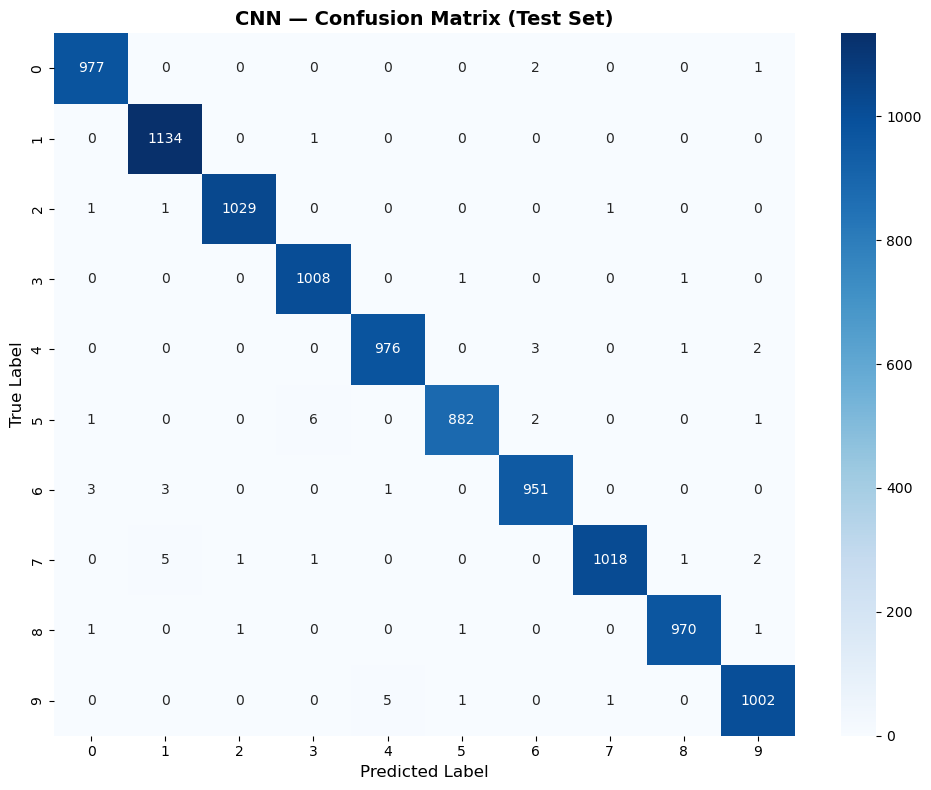

In [20]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_all_predictions(model, test_loader,device)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=list(range(10)),
    yticklabels=list(range(10))
)
plt.title('CNN — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
print('Classification Report:\n')
print(classification_report(
    true_labels, pred_labels,
    target_names=[f'Digit {i}' for i in range(10)]
))

Classification Report:

              precision    recall  f1-score   support

     Digit 0       0.99      1.00      1.00       980
     Digit 1       0.99      1.00      1.00      1135
     Digit 2       1.00      1.00      1.00      1032
     Digit 3       0.99      1.00      1.00      1010
     Digit 4       0.99      0.99      0.99       982
     Digit 5       1.00      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       1.00      0.99      0.99      1028
     Digit 8       1.00      1.00      1.00       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [22]:
torch.save(model.state_dict(), 'cnn_mnist_model.pth')
print('✅ Model saved to cnn_mnist_model.pth')

# ── To reload the model later ──────────────────────────────────
# model = CNN(num_classes=10)
# model.load_state_dict(torch.load('cnn_mnist_model.pth'))
# model.eval()

✅ Model saved to cnn_mnist_model.pth


## Defining_Our_RNN_Model

In [18]:
 INPUT_SIZE=28
 SEQUENCE_LENGTH=28
 HIDDEN_SIZE=128
 NUM_LAYERS=2
 NUM_CLASSES=10
 NUM_EPOCHS =10
 BATCH_SIZE=64
 LEARNING_RATE=0.001

In [19]:
class RNN_LSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN_LSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(                   # ── LSTM Layer ─────────────────────────────────────────────
            input_size  = input_size,          # input_size  : number of features per time step (28 pixels per row)
            hidden_size = hidden_size,         # hidden_size : number of LSTM units (memory cells)
            num_layers  = num_layers,          # num_layers  : stacked LSTM layers
            batch_first = True,                # batch_first : True → input shape is [batch, seq_len, features]
            dropout     = 0.3                  # dropout     : applied between stacked LSTM layers (only if num_layers > 1)
            )                                  # dropout between LSTM layers

        # ── Classifier ─────────────────────────────────────────────
        self.dropout    = nn.Dropout(p=0.3)
        self.fc         = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape coming in : [batch, 1, 28, 28]  (image tensor)  
        # We need: [batch, 28, 28] (sequence tensor)
        x = x.squeeze(1)   # remove channel dim → [batch, 28, 28]

        # Initialise hidden state and cell state with zeros
        # Shape: [num_layers, batch_size, hidden_size]
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Forward pass through LSTM
        # out shape: [batch, seq_len=28, hidden_size=128]
        
        out, (h_n, c_n) = self.lstm(x, (h0, c0))
        last_out = out[:, -1, :]           # Shape: [batch, hidden_size=128]
        last_out = self.dropout(last_out)  # dropout randomly off the neurons to prevent overfitting
        logits   = self.fc(last_out)       # [batch, num_classes=10]
        return logits


model = RNN_LSTM(
    input_size  = INPUT_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

RNN_LSTM(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 214,282


In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training&Evaluation

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """One full pass over training data."""
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in loader:
        optimizer.zero_grad()
        images = images.to(device)   # [batch, 1, 28, 28]
        labels = labels.to(device)

        # Forward pass — model internally reshapes to [batch, 28, 28]
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in RNNs
        # This is important and specific to RNNs!
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, dim=1)
        correct       += (predicted == labels).sum().item()
        total         += labels.size(0)

    return running_loss / len(loader), 100.0 * correct / total

In [30]:
def evaluate(model, loader, criterion, device):
    """Evaluate on test set — no gradient computation."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted  = torch.max(outputs, dim=1)
            correct       += (predicted == labels).sum().item()
            total         += labels.size(0)

    return running_loss / len(loader), 100.0 * correct / total

In [31]:
train_losses, train_accuracies = [], []
test_losses,  test_accuracies  = [], []

print('=' * 65)
for epoch in range(1, NUM_EPOCHS + 1):
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"epoch={epoch}/{NUM_EPOCHS} & loss={train_loss:.4f}")

print('=' * 65)
print(f'\n Best Test Accuracy : {max(test_accuracies):.2f}%')

epoch=1/10 & loss=0.1791
epoch=2/10 & loss=0.0738
epoch=3/10 & loss=0.0561
epoch=4/10 & loss=0.0455
epoch=5/10 & loss=0.0342
epoch=6/10 & loss=0.0335
epoch=7/10 & loss=0.0266
epoch=8/10 & loss=0.0237
epoch=9/10 & loss=0.0232
epoch=10/10 & loss=0.0177

 Best Test Accuracy : 99.41%


### Confusion_Matrix_For_RNN

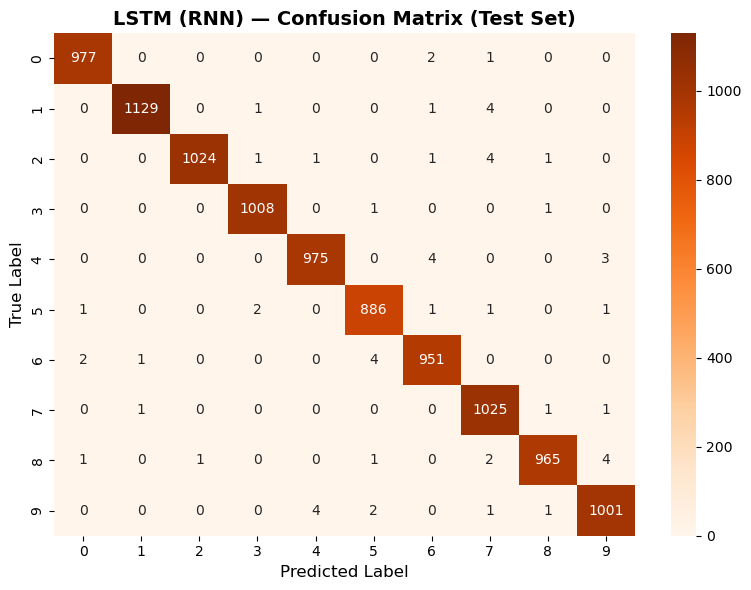

In [34]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

true_labels, pred_labels = get_all_predictions(model, test_loader, device)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=list(range(10)),
    yticklabels=list(range(10))
)
plt.title('LSTM (RNN) — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
print('Classification Report (LSTM / RNN):\n')
print(classification_report(
    true_labels, pred_labels,
    target_names=[f'Digit {i}' for i in range(10)]
))

Classification Report (LSTM / RNN):

              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      0.99      1.00      1135
     Digit 2       1.00      0.99      1.00      1032
     Digit 3       1.00      1.00      1.00      1010
     Digit 4       0.99      0.99      0.99       982
     Digit 5       0.99      0.99      0.99       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.99      1.00      0.99      1028
     Digit 8       1.00      0.99      0.99       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [36]:
torch.save(model.state_dict(), 'rnn_lstm_mnist_model.pth')
print('Model saved to rnn_lstm_mnist_model.pth')

# To reload:
# model = RNN_LSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)
# model.load_state_dict(torch.load('rnn_lstm_mnist_model.pth'))
# model.eval()

Model saved to rnn_lstm_mnist_model.pth


### CNN_vs_RNN_Comparision

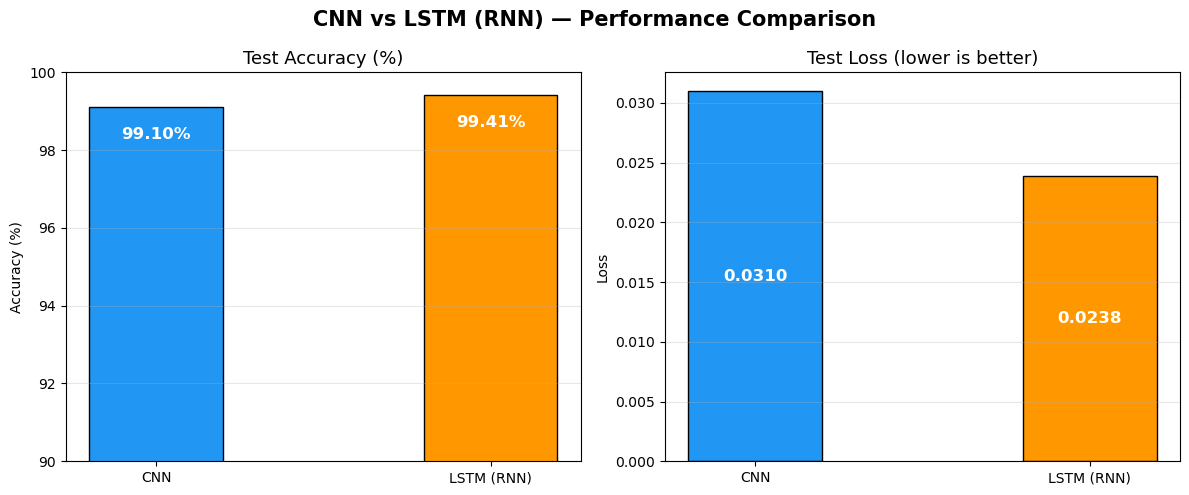

Model             Test Accuracy    Test Loss
CNN                      99.10%       0.0310
LSTM (RNN)               99.41%       0.0238

 Winner: LSTM (RNN)


In [37]:
# ── Paste your CNN results here ───────────────────────────────
# Replace these with actual values from your CNN notebook
cnn_test_acc  = 99.1   # example — update with your value
cnn_test_loss = 0.031  # example — update with your value

rnn_test_acc  = max(test_accuracies)
rnn_test_loss = min(test_losses)

# ── Bar chart comparison ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CNN vs LSTM (RNN) — Performance Comparison', fontsize=15, fontweight='bold')

models  = ['CNN', 'LSTM (RNN)']
colors  = ['#2196F3', '#FF9800']

# Accuracy bars
bars1 = ax1.bar(models, [cnn_test_acc, rnn_test_acc], color=colors, width=0.4, edgecolor='black')
ax1.set_title('Test Accuracy (%)', fontsize=13)
ax1.set_ylim([90, 100])
ax1.set_ylabel('Accuracy (%)')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, [cnn_test_acc, rnn_test_acc]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
             f'{val:.2f}%', ha='center', va='top', fontsize=12, fontweight='bold', color='white')

# Loss bars
bars2 = ax2.bar(models, [cnn_test_loss, rnn_test_loss], color=colors, width=0.4, edgecolor='black')
ax2.set_title('Test Loss (lower is better)', fontsize=13)
ax2.set_ylabel('Loss')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, [cnn_test_loss, rnn_test_loss]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{val:.4f}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────
print('=' * 45)
print(f'{"Model":<15} {"Test Accuracy":>15} {"Test Loss":>12}')
print('=' * 45)
print(f'{"CNN":<15} {cnn_test_acc:>14.2f}% {cnn_test_loss:>12.4f}')
print(f'{"LSTM (RNN)":<15} {rnn_test_acc:>14.2f}% {rnn_test_loss:>12.4f}')
print('=' * 45)
winner = 'CNN' if cnn_test_acc > rnn_test_acc else 'LSTM (RNN)'
print(f'\n Winner: {winner}')